<a href="https://colab.research.google.com/github/wagnervericek/git-journey/blob/main/House_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()  # dosya seçme penceresi açılır, zip'i seç

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip


In [2]:
import zipfile
with zipfile.ZipFile('house-prices-advanced-regression-techniques.zip', 'r') as z:
    z.extractall('house_data')

import os
os.listdir('house_data')

['data_description.txt', 'train.csv', 'sample_submission.csv', 'test.csv']

In [3]:
import pandas as pd
train = pd.read_csv('house_data/train.csv')
test = pd.read_csv('house_data/test.csv')

print(train.shape,test.shape)
train.head()

(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
train['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


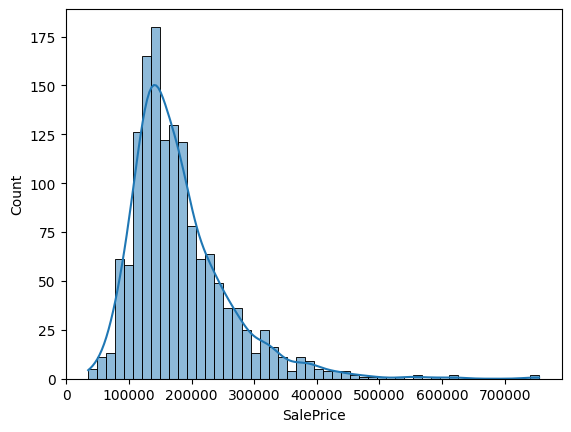

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(train['SalePrice'], bins=50, kde=True)
plt.show()

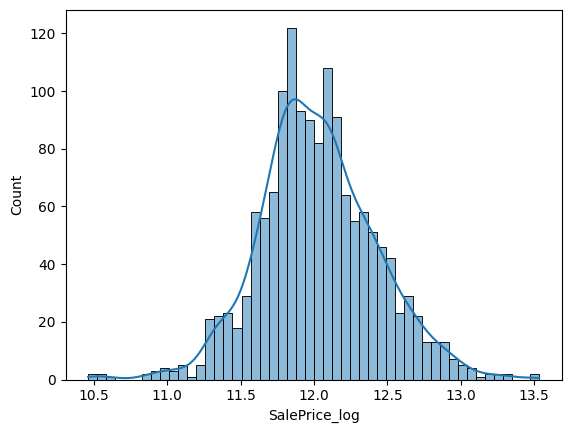

In [7]:
import numpy as np
train['SalePrice_log'] = np.log(train['SalePrice'])
sns.histplot(train['SalePrice_log'], bins=50, kde=True)
plt.show()

In [8]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(5))

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
Name: SalePrice, dtype: float64


In [9]:
print(corr.head(20))

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
Name: SalePrice, dtype: float64


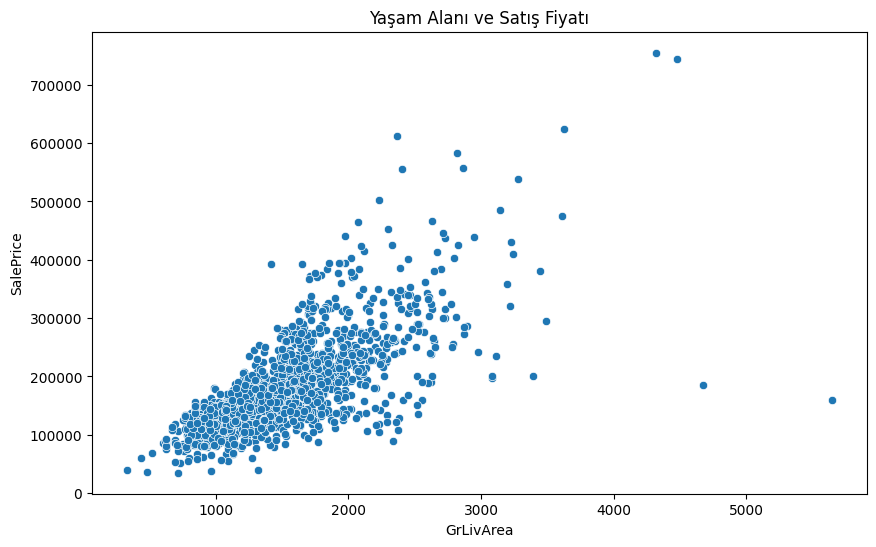

In [10]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=train,x='GrLivArea', y='SalePrice')
plt.title('Yaşam Alanı ve Satış Fiyatı')
plt.show()

In [11]:
# Bu iki outlier'ı at
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]
print(train.shape)

(1458, 82)


In [12]:
missing = (train.isnull().sum() / len(train) * 100 ).sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)


PoolQC          99.588477
MiscFeature     96.296296
Alley           93.758573
Fence           80.727023
MasVnrType      59.807956
FireplaceQu     47.325103
LotFrontage     17.764060
GarageQual       5.555556
GarageYrBlt      5.555556
GarageFinish     5.555556
GarageType       5.555556
GarageCond       5.555556
BsmtExposure     2.606310
BsmtFinType2     2.606310
BsmtQual         2.537723
BsmtFinType1     2.537723
BsmtCond         2.537723
MasVnrArea       0.548697
Electrical       0.068587
dtype: float64


In [13]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType',
             'FireplaceQu', 'GarageQual', 'GarageFinish', 'GarageType',
             'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtQual',
             'BsmtFinType1', 'BsmtCond']

for col in none_cols:
  train[col] = train[col].fillna('None')

train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

print(train.isnull().sum().sum())

0


In [14]:
categorical_cols = train.select_dtypes(include='object').columns.tolist()
print(len(categorical_cols))
print(categorical_cols)

43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [15]:
train_encoded = pd.get_dummies(train, columns=categorical_cols, drop_first=True)
print(train_encoded.shape)

(1458, 261)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

target = 'SalePrice_log'
drop_cols = ['Id', 'SalePrice', 'SalePrice_log']

X = train_encoded.drop(columns=drop_cols).values
y = train_encoded[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(1166, 258) (292, 258)


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'RMSE: {root_mean_squared_error(y_test, y_pred):.4f}')
print(f'R²: {r2_score(y_test, y_pred):.4f}')

RMSE: 0.1371
R²: 0.8884


In [18]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

y_pred_xgb = xgb_model.predict(X_test)
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_xgb):.4f}')
print(f'R²: {r2_score(y_test, y_pred_xgb):.4f}')

[0]	validation_0-rmse:0.40761
[100]	validation_0-rmse:0.22786
[200]	validation_0-rmse:0.16501
[300]	validation_0-rmse:0.14214
[400]	validation_0-rmse:0.13310
[500]	validation_0-rmse:0.12892
[600]	validation_0-rmse:0.12686
[700]	validation_0-rmse:0.12554
[800]	validation_0-rmse:0.12499
[900]	validation_0-rmse:0.12472
[999]	validation_0-rmse:0.12457
RMSE: 0.1246
R²: 0.9080


In [19]:
feature_names = train_encoded.drop(columns=drop_cols).columns.tolist()

importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(15))

               feature  importance
3          OverallQual    0.176370
25          GarageCars    0.062792
151       ExterQual_TA    0.049402
15           GrLivArea    0.041480
194       CentralAir_Y    0.035779
210   FireplaceQu_None    0.033897
5            YearBuilt    0.030255
26          GarageArea    0.025537
23          Fireplaces    0.022971
226      GarageQual_TA    0.017886
11         TotalBsmtSF    0.017545
21        KitchenAbvGr    0.016164
231      GarageCond_TA    0.015842
201     KitchenQual_TA    0.015099
217  GarageType_Detchd    0.014578


In [20]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler


scales = StandardScaler()
x_train_scaled = scales.fit_transform(X_train)
x_test_scaled = scales.transform(X_test)

x_train_t = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(x_train_t.shape, y_train_t.shape)

torch.Size([1166, 258]) torch.Size([1166])


In [21]:
class HousePriceNet(nn.Module):
  def __init__(self,input_dim):
    super().__init__()
    self.layer1 = nn.Linear(input_dim,128)
    self.layer2 = nn.Linear(128,64)
    self.layer3 = nn.Linear(64,32)
    self.layer4 = nn.Linear(32,1)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.3)

  def forward(self,x):
    x = self.relu(self.layer1(x))
    x = self.dropout(x)
    x = self.relu(self.layer2(x))
    x = self.dropout(x)
    x = self.relu(self.layer3(x))
    x = self.layer4(x)
    return x

model_nn = HousePriceNet(input_dim=258)
print(model_nn)

total_params = sum(p.numel() for p in model_nn.parameters())
print(f'Toplam parametre sayısı: {total_params}')


HousePriceNet(
  (layer1): Linear(in_features=258, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=32, bias=True)
  (layer4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)
Toplam parametre sayısı: 43521


In [22]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

epochs = 200
for epoch in range(epochs):
    model_nn.train()
    for batch_x, batch_y in train_loader:
        pred = model_nn(batch_x)
        loss = criterion(pred, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 20 == 0:
        model_nn.eval()
        with torch.no_grad():
            test_pred = model_nn(x_test_t)
            test_loss = criterion(test_pred, y_test_t)
        print(f'Epoch {epoch}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([14])) that is different to the input size (torch.Size([14, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([292])) that is different to the input size (torch.Size([292, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(inpu

Epoch 0, Train Loss: 67.6425, Test Loss: 54.1201
Epoch 20, Train Loss: 2.8412, Test Loss: 1.5129
Epoch 40, Train Loss: 2.1329, Test Loss: 1.6300
Epoch 60, Train Loss: 1.0284, Test Loss: 0.6953
Epoch 80, Train Loss: 0.7426, Test Loss: 0.4389
Epoch 100, Train Loss: 0.8988, Test Loss: 0.7411
Epoch 120, Train Loss: 0.4142, Test Loss: 0.8002
Epoch 140, Train Loss: 0.1937, Test Loss: 0.9726
Epoch 160, Train Loss: 0.1650, Test Loss: 0.6711
Epoch 180, Train Loss: 0.2726, Test Loss: 0.8644


In [23]:
print(x_train_t.shape, y_train_t.shape)
print(x_test_t.shape, y_test_t.shape)

torch.Size([1166, 258]) torch.Size([1166])
torch.Size([292, 258]) torch.Size([292])


In [24]:
y_train_t = y_train_t.view(-1,1)
y_test_t = y_test_t.view(-1,1)

In [25]:
train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [26]:
model_nn = HousePriceNet(input_dim = 258)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

best_loss = float('inf')
best_model_state = None
patience = 20
patience_counter = 0

epochs = 300
for epoch in range(epochs):
  model_nn.train()
  for batch_x, batch_y in train_loader:
    pred = model_nn(batch_x)
    loss = criterion(pred, batch_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  model_nn.eval()
  with torch.no_grad():
    test_pred = model_nn(x_test_t)
    test_loss = criterion(test_pred, y_test_t)

  if test_loss < best_loss:
    best_loss = test_loss
    best_model_state = model_nn.state_dict()
    patience_counter = 0
  else:
    patience_counter += 1

  if epoch % 20 == 0:
    print(f'Epoch {epoch}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

  if patience_counter >= patience:
    print(f'Early stopping at epoch {epoch}')

Epoch 0, Train Loss: 14.3289, Test Loss: 8.1784
Epoch 20, Train Loss: 2.8353, Test Loss: 1.2983
Epoch 40, Train Loss: 2.0188, Test Loss: 0.5843
Epoch 60, Train Loss: 0.5565, Test Loss: 0.7913
Epoch 80, Train Loss: 0.5673, Test Loss: 0.2976
Epoch 100, Train Loss: 0.2316, Test Loss: 0.2586
Early stopping at epoch 101
Early stopping at epoch 102
Early stopping at epoch 103
Early stopping at epoch 104
Early stopping at epoch 105
Early stopping at epoch 106
Early stopping at epoch 107
Early stopping at epoch 108
Early stopping at epoch 109
Early stopping at epoch 110
Early stopping at epoch 111
Early stopping at epoch 112
Early stopping at epoch 113
Early stopping at epoch 114
Early stopping at epoch 115
Early stopping at epoch 116
Early stopping at epoch 117
Early stopping at epoch 118
Early stopping at epoch 119
Epoch 120, Train Loss: 0.0869, Test Loss: 0.5648
Early stopping at epoch 120
Early stopping at epoch 121
Early stopping at epoch 122
Early stopping at epoch 123
Early stopping at 

In [27]:
model_nn.eval()
with torch.no_grad():
  final_pred = model_nn(x_test_t).numpy()
print(f"Test R²: {r2_score(y_test, final_pred):.4f}")

Test R²: 0.6206


In [28]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

y_pred_xgb = xgb_model.predict(X_test)

print(f'RMSE: {root_mean_squared_error(y_test, y_pred_xgb):.4f}')
print(f'R²: {r2_score(y_test, y_pred_xgb):.4f}')

[0]	validation_0-rmse:0.40761
[100]	validation_0-rmse:0.22786
[200]	validation_0-rmse:0.16501
[300]	validation_0-rmse:0.14214
[400]	validation_0-rmse:0.13310
[500]	validation_0-rmse:0.12892
[600]	validation_0-rmse:0.12686
[700]	validation_0-rmse:0.12554
[800]	validation_0-rmse:0.12499
[900]	validation_0-rmse:0.12472
[999]	validation_0-rmse:0.12457
RMSE: 0.1246
R²: 0.9080


In [29]:
test = pd.read_csv('house_data/test.csv')
test_ids = test['Id'].copy()

# Aynı None doldurma
for col in none_cols:
    test[col] = test[col].fillna('None')

# Aynı sayısal doldurma (train'den öğrenilen değerlerle!)
test['LotFrontage'] = test['LotFrontage'].fillna(train['LotFrontage'].median())
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)
test['Electrical'] = test['Electrical'].fillna(train['Electrical'].mode()[0])

print(test.isnull().sum().sum())

22


In [30]:
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0]
print(missing_test)

MSZoning        4
Utilities       2
Exterior1st     1
Exterior2nd     1
BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
BsmtFullBath    2
BsmtHalfBath    2
KitchenQual     1
Functional      2
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64


In [31]:
cat_cols_to_fill = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
                     'KitchenQual', 'Functional', 'SaleType']

for col in cat_cols_to_fill:
    test[col] = test[col].fillna(train[col].mode()[0])

num_cols_to_fill = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                     'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']

for col in num_cols_to_fill:
    test[col] = test[col].fillna(0)

print(test.isnull().sum().sum())

0


In [32]:
test_encoded = pd.get_dummies(test,columns=categorical_cols,drop_first=True)
print(test_encoded.shape)
print(train_encoded.shape)

(1459, 242)
(1458, 261)


In [33]:
train_cols = train_encoded.drop(columns=['Id','SalePrice','SalePrice_log']).columns

test_final = test_encoded.reindex(columns=train_cols,fill_value=0)

print(test_final.shape)

(1459, 258)


In [34]:
x_submission = test_final.values

pred_log = xgb_model.predict(x_submission)
pred_price = np.expm1(pred_log)

print(pred_price[:10])

[122111.03 151305.52 183365.25 191098.97 192151.06 181866.97 176134.03
 168815.67 188590.38 123120.66]


In [35]:
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': pred_price
})

print(submission.head())
print(submission.shape)

submission.to_csv('submission.csv', index=False)

     Id      SalePrice
0  1461  122111.031250
1  1462  151305.515625
2  1463  183365.250000
3  1464  191098.968750
4  1465  192151.062500
(1459, 2)


In [36]:
sample = pd.read_csv('house_data/sample_submission.csv')
print(sample.head())

     Id      SalePrice
0  1461  169277.052498
1  1462  187758.393989
2  1463  183583.683570
3  1464  179317.477511
4  1465  150730.079977


In [37]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# Toplam kullanılabilir alan
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

# Evin yaşı (satıldığı yıl - yapıldığı yıl)
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

# Yenilenmeden bu yana geçen süre
train['YearsSinceRemodel'] = train['YrSold'] - train['YearRemodAdd']
test['YearsSinceRemodel'] = test['YrSold'] - test['YearRemodAdd']

# Toplam banyo sayısı
train['TotalBath'] = train['FullBath'] + 0.5*train['HalfBath'] + train['BsmtFullBath'] + 0.5*train['BsmtHalfBath']
test['TotalBath'] = test['FullBath'] + 0.5*test['HalfBath'] + test['BsmtFullBath'] + 0.5*test['BsmtHalfBath']

print(train[['TotalSF', 'HouseAge', 'YearsSinceRemodel', 'TotalBath']].head())

   TotalSF  HouseAge  YearsSinceRemodel  TotalBath
0     2566         5                  5        3.5
1     2524        31                 31        2.5
2     2706         7                  6        3.5
3     2473        91                 36        2.0
4     3343         8                  8        3.5


In [39]:
new_features = ['TotalSF','HouseAge','YearsSinceRemodel','TotalBath']
for col in new_features:
  print(col,train[col].corr(train['SalePrice']))

TotalSF 0.8328770355221619
HouseAge -0.5240670055640875
YearsSinceRemodel -0.5097057958391055
TotalBath 0.6358962975612399


In [40]:
train_encoded = pd.get_dummies(train,columns=categorical_cols,drop_first=True)
test_encoded = pd.get_dummies(test,columns=categorical_cols,drop_first=True)

print(train_encoded.shape,test_encoded.shape)

train_cols = train_encoded.drop(columns=['Id', 'SalePrice', 'SalePrice_log']).columns

print(test_final.shape)

target = 'SalePrice_log'
drop_cols = ['Id','SalePrice','SalePrice_log']

X = train_encoded.drop(columns=drop_cols).values
y = train_encoded[target].values

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(x_train.shape,x_test.shape)
#


(1458, 265) (1459, 246)
(1459, 258)
(1166, 262) (292, 262)


In [41]:
xgb_model_v2 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs = -1,
    early_stopping_rounds=50
)

xgb_model_v2.fit(
    x_train,y_train,
    eval_set=[(x_test,y_test)],
    verbose=100
)

y_pred_v2 = xgb_model_v2.predict(x_test)
print(f'RMSE: {root_mean_squared_error(y_test,y_pred_v2):.4f}')
print(f'R²: {r2_score(y_test,y_pred_v2):.4f}')
#

[0]	validation_0-rmse:0.40742
[100]	validation_0-rmse:0.22450
[200]	validation_0-rmse:0.16461
[300]	validation_0-rmse:0.14261
[400]	validation_0-rmse:0.13386
[500]	validation_0-rmse:0.12931
[600]	validation_0-rmse:0.12714
[700]	validation_0-rmse:0.12578
[800]	validation_0-rmse:0.12491
[900]	validation_0-rmse:0.12455
[999]	validation_0-rmse:0.12415
RMSE: 0.1242
R²: 0.9086


In [42]:
feature_names = train_encoded.drop(columns=drop_cols).columns.tolist()

importance_v2 = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model_v2.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_v2.head(15))

              feature  importance
3         OverallQual    0.148615
36            TotalSF    0.128271
155      ExterQual_TA    0.055395
25         GarageCars    0.039461
198      CentralAir_Y    0.039021
205    KitchenQual_TA    0.027118
39          TotalBath    0.027099
214  FireplaceQu_None    0.023449
235     GarageCond_TA    0.017297
21       KitchenAbvGr    0.016299
23         Fireplaces    0.015492
37           HouseAge    0.014741
26         GarageArea    0.014418
43        MSZoning_RM    0.014208
15          GrLivArea    0.013342


In [43]:
test_final = test_encoded.reindex(columns=train_cols, fill_value=0)
print(test_final.shape)

(1459, 262)


In [44]:
X_submission = test_final.values

pred_log_v2 = xgb_model_v2.predict(X_submission)
pred_price_v2 = np.expm1(pred_log_v2)

submission_v2 = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': pred_price_v2
})

submission_v2.to_csv('submission_v2.csv', index=False)

from google.colab import files
files.download('submission_v2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
from sklearn.model_selection import cross_val_score, KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs = -1
)

x_full = train_encoded.drop(columns=drop_cols).values
y_full = train_encoded[target].values

scores = cross_val_score(xgb_cv_model, x_full, y_full, cv=kfold, scoring='neg_root_mean_squared_error')

print('Her fold RMSE:', -scores)
print('Ortalama RMSE:', -scores.mean())
print('Std:', scores.std())


Her fold RMSE: [0.12379423 0.11057404 0.12150198 0.13085026 0.11165146]
Ortalama RMSE: 0.11967439348374634
Std: 0.007647182627858585


In [46]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [300, 500, 800, 1000],
    'learning_rate': [0.005, 0.01, 0.03, 0.05],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9]
}

xgb_base = XGBRegressor(random_state=42,n_jobs= -1)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs = -1,
    random_state=42
)

random_search.fit(x_full, y_full)

print('En iyi parametreler:', random_search.best_params_)
print('En iyi RMSE:', -random_search.best_score_)



Fitting 5 folds for each of 30 candidates, totalling 150 fits
En iyi parametreler: {'subsample': 0.6, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
En iyi RMSE: 0.1173649979887007


In [47]:
best_xgb = XGBRegressor(**random_search.best_params_,random_state=42,n_jobs=-1)
best_xgb.fit(x_train, y_train)

y_pred_best = best_xgb.predict(x_test)
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_best):.4f}')
print(f'R²: {r2_score(y_test, y_pred_best):.4f}')
#

RMSE: 0.1215
R²: 0.9124


In [48]:
pred_log_best = best_xgb.predict(X_submission)
pred_price_best = np.expm1(pred_log_best)

submission_best = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': pred_price_best
})

submission_best.to_csv('submission_best.csv', index=False)

from google.colab import files
files.download('submission_best.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor

lr_model = LinearRegression()
lr_model.fit(x_train,y_train)

lgbm_model = LGBMRegressor(
    n_estimators = 1000,
    learning_rate = 0.01,
    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    n_jobs = -1,
    verbose= -1
)
lgbm_model.fit(x_train,y_train)

pred_lr = lr_model.predict(x_test)
pred_lgbm = lgbm_model.predict(x_test)
pred_xgb = best_xgb.predict(x_test)

pred_blend = (pred_lr + pred_lgbm + pred_xgb)/3


print(f'Linear R²: {r2_score(y_test, pred_lr):.4f}')
print(f'LightGBM R²: {r2_score(y_test, pred_lgbm):.4f}')
print(f'XGBoost R²: {r2_score(y_test, pred_xgb):.4f}')
print(f'Blend R²: {r2_score(y_test, pred_blend):.4f}')

Linear R²: 0.8884
LightGBM R²: 0.9079
XGBoost R²: 0.9124
Blend R²: 0.9174


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [50]:
pred_weighted = (0.15 * pred_lr + 0.40 * pred_lgbm + 0.45 * pred_xgb)
print(f'Weighted Blend R²: {r2_score(y_test, pred_weighted):.4f}')

Weighted Blend R²: 0.9160


In [51]:
best_r2 = 0
best_weights = None

for w_lr in np.arange(0,0.4,0.05):
  for w_lgbm in np.arange(0,0.6,0.05):
      w_xgb = 1- w_lr - w_lgbm
      if w_xgb < 0 or w_xgb > 1:
        continue
      pred_weighted = (w_lr * pred_lr + w_lgbm * pred_lgbm + w_xgb * pred_xgb)
      r2 = r2_score(y_test, pred_weighted)
      if r2 > best_r2:
        best_r2 = r2
        best_weights = (w_lr, w_lgbm, w_xgb)

print('En iyi ağırlıklar:', best_weights)
print('En iyi R²:', best_r2)

En iyi ağırlıklar: (np.float64(0.30000000000000004), np.float64(0.15000000000000002), np.float64(0.5499999999999999))
En iyi R²: 0.9177369162951186


In [52]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lgbm_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)

best_xgb = XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)
best_xgb.fit(X_train, y_train)

print(X_train.shape, X_submission.shape)

(1166, 258) (1459, 262)


In [53]:
pred_lr_sub = lr_model.predict(x_submission)
pred_lgbm_sub = lgbm_model.predict(x_submission)
pred_xgb_sub = best_xgb.predict(x_submission)

pred_blend_sub = (pred_lr_sub + pred_lgbm_sub + pred_xgb_sub)/3
pred_price_blend = np.expm1(pred_blend_sub)

submission_blend = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': pred_price_blend
})

submission_blend.to_csv('submission_blend.csv', index=False)

from google.colab import files
files.download('submission_blend.csv')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
print(f'Linear R²: {r2_score(y_test, lr_model.predict(X_test)):.4f}')
print(f'LightGBM R²: {r2_score(y_test, lgbm_model.predict(X_test)):.4f}')
print(f'XGBoost R²: {r2_score(y_test, best_xgb.predict(X_test)):.4f}')

Linear R²: 0.8884
LightGBM R²: 0.9057
XGBoost R²: 0.9134


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [55]:
best_xgb = XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)
best_xgb.fit(X_train, y_train)

print(best_xgb.n_features_in_)  # 262 olmalı
print(X_submission.shape[1])     # 262 olmalı

258
262


In [56]:
target = 'SalePrice_log'
drop_cols = ['Id', 'SalePrice', 'SalePrice_log']

X_full = train_encoded.drop(columns=drop_cols).values
y_full = train_encoded[target].values

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, X_submission.shape)

(1166, 262) (292, 262) (1459, 262)


In [57]:
best_xgb = XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)
best_xgb.fit(X_train, y_train)

print(f'R²: {r2_score(y_test, best_xgb.predict(X_test)):.4f}')

R²: 0.9124


In [58]:
pred_log_final = best_xgb.predict(X_submission)
pred_price_final = np.expm1(pred_log_final)

submission_final = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': pred_price_final
})

submission_final.to_csv('submission_final.csv', index=False)

from google.colab import files
files.download('submission_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

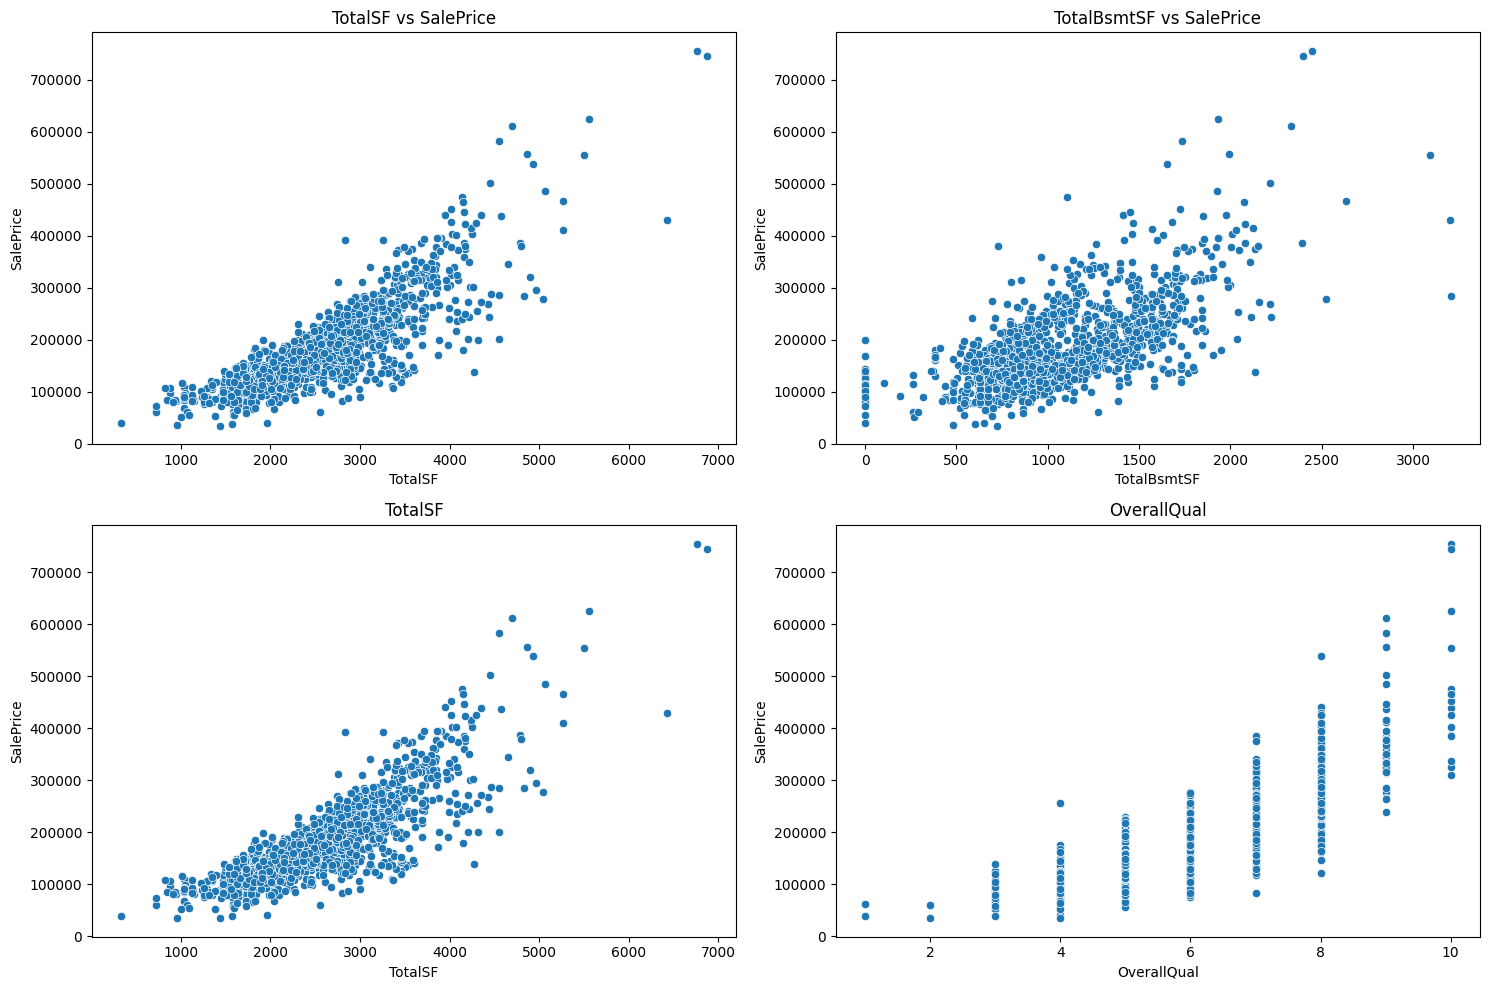

In [59]:
fig,axes = plt.subplots(2,2,figsize=(15,10))

sns.scatterplot(data=train,x='TotalSF',y='SalePrice',ax=axes[0,0])
axes[0,0].set_title('TotalSF vs SalePrice')

sns.scatterplot(data=train,x='TotalBsmtSF',y='SalePrice',ax=axes[0,1])
axes[0,1].set_title('TotalBsmtSF vs SalePrice')

sns.scatterplot(data=train,x='TotalSF',y='SalePrice',ax=axes[1,0])
axes[1,0].set_title('TotalSF')

sns.scatterplot(data=train,x='OverallQual',y='SalePrice',ax=axes[1,1])
axes[1,1].set_title('OverallQual')

plt.tight_layout()
plt.show()

In [60]:
outlier_check = train[(train['TotalSF'] > 6000) & (train['SalePrice'] < 500000)]
print(outlier_check[['Id', 'TotalSF', 'GrLivArea', 'OverallQual', 'SalePrice']])

      Id  TotalSF  GrLivArea  OverallQual  SalePrice
496  497     6428       3228            8     430000


In [61]:
train_pred = best_xgb.predict(x_train)
residuals = np.abs(y_train - train_pred)

worst_idx = np.argsort(residuals)[-10:]
print('En büyük hatalar (log ölceğinde):',residuals[worst_idx])

En büyük hatalar (log ölceğinde): [0.27768882 0.27856557 0.28471199 0.29725314 0.31445051 0.32971518
 0.38384419 0.45637013 0.49248406 0.60596391]


In [62]:
train_indices = train_encoded.drop(columns=drop_cols).reset_index(drop=True)
x_train_idx,x_test_idx = train_test_split(train_encoded.index,test_size=0.2,random_state=42)

worst_original_idx = x_train_idx[worst_idx]
worst_houses = train.loc[worst_original_idx,['Id', 'GrLivArea', 'TotalSF', 'OverallQual', 'SalePrice']]
worst_houses['residual'] = residuals[worst_idx]
print(worst_houses.sort_values('residual',ascending=False))

        Id  GrLivArea  TotalSF  OverallQual  SalePrice  residual
632    633       1411     2797            7      82500  0.605964
462    463        864     1728            5      62383  0.492484
1324  1325       1795     3590            8     147000  0.456370
970    971       1192     1912            4     135000  0.383844
1453  1454       1140     2280            5      84500  0.329715
688    689       1419     2838            8     392000  0.314451
812    813       1044     1584            5      55993  0.297253
410    411       1276     2552            5      60000  0.284712
495    496        720     1440            4      34900  0.278566
588    589       1473     2910            5     143000  0.277689


In [63]:
print(train.loc[[632,462,1324,970],['Id','SaleCondition','SalePrice']])

        Id SaleCondition  SalePrice
632    633        Family      82500
462    463        Normal      62383
1324  1325       Partial     147000
970    971       Abnorml     135000


In [64]:
threshold = np.percentile(residuals, 99)
print('Eşik:', threshold)

outlier_mask = residuals > threshold
print('Atılacak satır sayısı:', outlier_mask.sum())

Eşik: 0.25292467443444133
Atılacak satır sayısı: 12


In [65]:
# Bu 12 satırın orijinal Id'lerini bul
outlier_original_idx = x_train_idx[outlier_mask]
outlier_ids = train.loc[outlier_original_idx, 'Id'].values
print('Atılacak Id\'ler:', outlier_ids)

# Train'den bu satırları çıkar
train_clean_final = train[~train['Id'].isin(outlier_ids)].copy()
print(train_clean_final.shape)

Atılacak Id'ler: [ 463  411  633  813 1325  875 1454  496  589  659  971  689]
(1446, 86)


In [66]:
# --- Encoding'i yeni (temizlenmiş) veriyle tekrar yap ---
train_encoded_v3 = pd.get_dummies(train_clean_final, columns=categorical_cols, drop_first=True)
test_encoded_v3 = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

train_cols_v3 = train_encoded_v3.drop(columns=['Id', 'SalePrice', 'SalePrice_log']).columns
test_final_v3 = test_encoded_v3.reindex(columns=train_cols_v3, fill_value=0)

X_full_v3 = train_encoded_v3.drop(columns=['Id', 'SalePrice', 'SalePrice_log']).values
y_full_v3 = train_encoded_v3['SalePrice_log'].values

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_full_v3, y_full_v3, test_size=0.2, random_state=42
)

print(X_train_v3.shape, X_test_v3.shape, test_final_v3.shape)

(1156, 262) (290, 262) (1459, 262)


In [67]:
xgb_v3 = XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)
xgb_v3.fit(X_train_v3, y_train_v3)

y_pred_v3 = xgb_v3.predict(X_test_v3)
print(f'RMSE: {root_mean_squared_error(y_test_v3, y_pred_v3):.4f}')
print(f'R²: {r2_score(y_test_v3, y_pred_v3):.4f}')

RMSE: 0.1180
R²: 0.9131


In [68]:
scores_v3 = cross_val_score(
    XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1),
    X_full_v3, y_full_v3, cv=kfold, scoring='neg_root_mean_squared_error'
)
print('Ortalama RMSE:', -scores_v3.mean())
print('Std:', scores_v3.std())

Ortalama RMSE: 0.1071441642628718
Std: 0.006850347123903828


In [69]:
pred_log_v3 = xgb_v3.predict(test_final_v3.values)
pred_price_v3 = np.expm1(pred_log_v3)

submission_v3 = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': pred_price_v3
})

submission_v3.to_csv('submission_v3.csv', index=False)

from google.colab import files
files.download('submission_v3.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
print(train['SaleCondition'].value_counts())


SaleCondition
Normal     1198
Partial     123
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64


In [71]:
train.groupby('SaleCondition')['SalePrice'].agg(['mean', 'median', 'count'])

,mean,median,count
SaleCondition,,,
Abnorml,146526.623762,130000.0,101
AdjLand,104125.000000,104000.0,4
Alloca,167377.416667,148145.0,12
Family,149600.000000,140500.0,20
Normal,175202.219533,160000.0,1198
Partial,273916.414634,246578.0,123


In [72]:
feature_names_v3 = train_encoded_v3.drop(columns=['Id', 'SalePrice', 'SalePrice_log']).columns.tolist()

importance_v3 = pd.DataFrame({
    'feature': feature_names_v3,
    'importance': xgb_v3.feature_importances_
}).sort_values('importance', ascending=False)

sale_condition_features = importance_v3[importance_v3['feature'].str.contains('SaleCondition')]
print(sale_condition_features)
print('\nGenel top 10:')
print(importance_v3.head(10))

                   feature  importance
260   SaleCondition_Normal    0.001717
261  SaleCondition_Partial    0.001677
259   SaleCondition_Family    0.001284
257  SaleCondition_AdjLand    0.000000
258   SaleCondition_Alloca    0.000000

Genel top 10:
              feature  importance
3         OverallQual    0.118014
155      ExterQual_TA    0.093343
36            TotalSF    0.083100
25         GarageCars    0.049839
214  FireplaceQu_None    0.034666
37           HouseAge    0.027302
39          TotalBath    0.025949
205    KitchenQual_TA    0.025852
15          GrLivArea    0.023908
23         Fireplaces    0.019684


In [73]:
# Train'den mahalle bazlı ortalama log fiyat hesapla
neighborhood_price = train_clean_final.groupby('Neighborhood')['SalePrice_log'].mean()
print(neighborhood_price.sort_values(ascending=False))

Neighborhood
NoRidge    12.676000
NridgHt    12.619411
StoneBr    12.573256
Timber     12.363455
Veenker    12.344176
Somerst    12.301181
ClearCr    12.253578
Crawfor    12.206659
Blmngtn    12.169416
CollgCr    12.163641
Gilbert    12.155803
NWAmes     12.141860
SawyerW    12.090689
Mitchel    11.946228
NAmes      11.869997
NPkVill    11.866477
SWISU      11.838435
Blueste    11.826536
Sawyer     11.822021
Edwards    11.712571
OldTown    11.709212
BrkSide    11.679727
BrDale     11.547864
IDOTRR     11.489762
MeadowV    11.474522
Name: SalePrice_log, dtype: float64


In [74]:
neighborhood_rank = neighborhood_price.rank().to_dict()

train_clean_final['NeighborhoodRank'] = train_clean_final['Neighborhood'].map(neighborhood_rank)
test['NeighborhoodRank'] = test['Neighborhood'].map(neighborhood_rank)

# Test'te olmayan bir mahalle varsa (train'de yoksa) ortalama rank ile doldur
test['NeighborhoodRank'] = test['NeighborhoodRank'].fillna(neighborhood_rank_mean := np.mean(list(neighborhood_rank.values())))

print(train_clean_final[['Neighborhood', 'NeighborhoodRank']].head())

  Neighborhood  NeighborhoodRank
0      CollgCr              16.0
1      Veenker              21.0
2      CollgCr              16.0
3      Crawfor              18.0
4      NoRidge              25.0


In [75]:
# Encoding'i tekrar yap (yeni feature dahil)
train_encoded_v4 = pd.get_dummies(train_clean_final, columns=categorical_cols, drop_first=True)
test_encoded_v4 = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

train_cols_v4 = train_encoded_v4.drop(columns=['Id', 'SalePrice', 'SalePrice_log']).columns
test_final_v4 = test_encoded_v4.reindex(columns=train_cols_v4, fill_value=0)

X_full_v4 = train_encoded_v4.drop(columns=['Id', 'SalePrice', 'SalePrice_log']).values
y_full_v4 = train_encoded_v4['SalePrice_log'].values

X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_full_v4, y_full_v4, test_size=0.2, random_state=42
)

print(X_train_v4.shape, test_final_v4.shape)

# Cross-validation ile test et
scores_v4 = cross_val_score(
    XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1),
    X_full_v4, y_full_v4, cv=kfold, scoring='neg_root_mean_squared_error'
)
print('Ortalama RMSE:', -scores_v4.mean())

(1156, 263) (1459, 263)
Ortalama RMSE: 0.10697560036735254


In [76]:
xgb_v4 = XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)
xgb_v4.fit(X_train_v4, y_train_v4)

y_pred_v4 = xgb_v4.predict(X_test_v4)
print(f'R²: {r2_score(y_test_v4, y_pred_v4):.4f}')

pred_log_v4 = xgb_v4.predict(test_final_v4.values)
pred_price_v4 = np.expm1(pred_log_v4)

submission_v4 = pd.DataFrame({'Id': test_ids, 'SalePrice': pred_price_v4})
submission_v4.to_csv('submission_v4.csv', index=False)

from google.colab import files
files.download('submission_v4.csv')

R²: 0.9169


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
from scipy.stats import skew

numeric_feats = train_clean_final.select_dtypes(include=[np.number]).columns
numeric_feats = [c for c in numeric_feats if c not in ['Id','SalePrice','SalePrice_log']]

skewness = train_clean_final[numeric_feats].apply(lambda x : skew(x.dropna()))
skewness = skewness.sort_values(ascending=False)
print(skewness.head(15))
#

MiscVal          24.334351
PoolArea         15.866055
LotArea          12.557007
3SsnPorch        10.242946
LowQualFinSF      8.957238
KitchenAbvGr      4.459111
BsmtFinSF2        4.239749
BsmtHalfBath      4.108111
ScreenPorch       4.099176
EnclosedPorch     3.093140
MasVnrArea        2.691863
OpenPorchSF       2.195758
LotFrontage       1.715949
WoodDeckSF        1.539662
MSSubClass        1.396400
dtype: float64


In [78]:
skewed_feats = skewness[abs(skewness) > 0.75].index.tolist()
print(len(skewed_feats),'feature log dönüşüm alacak')

for feat in skewed_feats:
  train_clean_final[feat] = np.log1p(train_clean_final[feat])
  test[feat] = np.log1p(test[feat])

print('Tamamlandı')

22 feature log dönüşüm alacak
Tamamlandı


In [79]:
train_encoded_v5 = pd.get_dummies(train_clean_final, columns=categorical_cols, drop_first=True)
test_encoded_v5 = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

train_cols_v5 = train_encoded_v5.drop(columns=['Id', 'SalePrice', 'SalePrice_log']).columns
test_final_v5 = test_encoded_v5.reindex(columns=train_cols_v5, fill_value=0)

X_full_v5 = train_encoded_v5.drop(columns=['Id', 'SalePrice', 'SalePrice_log']).values
y_full_v5 = train_encoded_v5['SalePrice_log'].values

scores_v5 = cross_val_score(
    XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1),
    X_full_v5, y_full_v5, cv=kfold, scoring='neg_root_mean_squared_error'
)
print('Ortalama RMSE:', -scores_v5.mean())

Ortalama RMSE: 0.10697560036735254


In [80]:
x_train_v5, x_test_v5, y_train_v5, y_test_v5 = train_test_split(
    X_full_v5, y_full_v5, test_size=0.2, random_state=42
)

print(x_train_v5.shape, x_test_v5.shape)

(1156, 263) (290, 263)


In [81]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

In [82]:
base_models_v2 = [
    ('xgb', XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)),
    ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, max_depth=4,
                            subsample=0.8, colsample_bytree=0.8, random_state=42,
                            n_jobs=-1, verbose=-1))
]

stacking_model_v2 = StackingRegressor(
    estimators=base_models_v2,
    final_estimator=Ridge(alpha=1.0),
    cv=5
)

stacking_model_v2.fit(x_train_v5, y_train_v5)
y_pred_stack_v2 = stacking_model_v2.predict(x_test_v5)
print(f'Stacking v2 R²: {r2_score(y_test_v5, y_pred_stack_v2):.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Stacking v2 R²: 0.9166


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [83]:
pred_log_stack = stacking_model_v2.predict(test_final_v5.values)
pred_price_stack = np.expm1(pred_log_stack)

submission_stack = pd.DataFrame({'Id': test_ids, 'SalePrice': pred_price_stack})
submission_stack.to_csv('submission_stack.csv', index=False)

from google.colab import files
files.download('submission_stack.csv')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [84]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

In [85]:
train_clean_final['Qual_x_SF'] = train_clean_final['OverallQual'] * train_clean_final['TotalSF']
test['Qual_x_SF'] = test['OverallQual'] * test['TotalSF']

train_clean_final['NeverRemodeled'] = (train_clean_final['YearBuilt'] == train_clean_final['YearRemodAdd']).astype(int)
test['NeverRemodeled'] = (test['YearBuilt'] == test['YearRemodAdd']).astype(int)

train_clean_final['OutdoorSF'] = (train_clean_final['WoodDeckSF'] + train_clean_final['OpenPorchSF'] +
                                    train_clean_final['EnclosedPorch'] + train_clean_final['3SsnPorch'] +
                                    train_clean_final['ScreenPorch'])
test['OutdoorSF'] = (test['WoodDeckSF'] + test['OpenPorchSF'] +
                      test['EnclosedPorch'] + test['3SsnPorch'] +
                      test['ScreenPorch'])

train_clean_final['Qual_x_Neighborhood'] = train_clean_final['OverallQual'] * train_clean_final['NeighborhoodRank']
test['Qual_x_Neighborhood'] = test['OverallQual'] * test['NeighborhoodRank']

print('Feature\'lar eklendi')

Feature'lar eklendi


In [86]:
print('NeighborhoodRank' in test.columns)

True


In [87]:
train_encoded_v6 = pd.get_dummies(train_clean_final, columns=categorical_cols, drop_first=True)
test_encoded_v6 = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

train_cols_v6 = train_encoded_v6.drop(columns=['Id', 'SalePrice', 'SalePrice_log']).columns
test_final_v6 = test_encoded_v6.reindex(columns=train_cols_v6, fill_value=0)

x_full_v6 = train_encoded_v6.drop(columns=['Id', 'SalePrice', 'SalePrice_log']).values
y_full_v6 = train_encoded_v6['SalePrice_log'].values

print(x_full_v6.shape)

scores_v6 = cross_val_score(
    XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1),
    x_full_v6, y_full_v6, cv=kfold, scoring='neg_root_mean_squared_error'
)
print('Ortalama RMSE:', -scores_v6.mean())

(1446, 267)
Ortalama RMSE: 0.10902643400213319


In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, root_mean_squared_error
from xgboost import XGBRegressor

# --- 1. Veriyi oku ---
train = pd.read_csv('house_data/train.csv')
test = pd.read_csv('house_data/test.csv')
test_ids = test['Id'].copy()

# --- 2. Outlier temizliği (GrLivArea bazlı) ---
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))].copy()

# --- 3. Log dönüşümü ---
train['SalePrice_log'] = np.log1p(train['SalePrice'])

# --- 4. Eksik veri: None ile doldurulacaklar ---
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType',
             'FireplaceQu', 'GarageQual', 'GarageFinish', 'GarageType',
             'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtQual',
             'BsmtFinType1', 'BsmtCond']

for col in none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

# --- 5. Eksik veri: sayısal ---
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())
test['LotFrontage'] = test['LotFrontage'].fillna(train['LotFrontage'].median())

train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)

train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

cat_cols_to_fill = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
                     'KitchenQual', 'Functional', 'SaleType']
for col in cat_cols_to_fill:
    test[col] = test[col].fillna(train[col].mode()[0])

num_cols_to_fill = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                     'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']
for col in num_cols_to_fill:
    test[col] = test[col].fillna(0)

# --- 6. Feature engineering (sadece işe yarayanlar) ---
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

train['YearsSinceRemodel'] = train['YrSold'] - train['YearRemodAdd']
test['YearsSinceRemodel'] = test['YrSold'] - test['YearRemodAdd']

train['TotalBath'] = train['FullBath'] + 0.5*train['HalfBath'] + train['BsmtFullBath'] + 0.5*train['BsmtHalfBath']
test['TotalBath'] = test['FullBath'] + 0.5*test['HalfBath'] + test['BsmtFullBath'] + 0.5*test['BsmtHalfBath']

# --- 7. Residual bazlı outlier temizliği için gereken ilk model ---
categorical_cols = train.select_dtypes(include='object').columns.tolist()
train_encoded_tmp = pd.get_dummies(train, columns=categorical_cols, drop_first=True)

target = 'SalePrice_log'
drop_cols = ['Id', 'SalePrice', 'SalePrice_log']

x_tmp = train_encoded_tmp.drop(columns=drop_cols).values
y_tmp = train_encoded_tmp[target].values

x_train_tmp, x_test_tmp, y_train_tmp, y_test_tmp = train_test_split(x_tmp, y_tmp, test_size=0.2, random_state=42)

xgb_tmp = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=4,
                        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb_tmp.fit(x_train_tmp, y_train_tmp)

train_pred_tmp = xgb_tmp.predict(x_train_tmp)
residuals = np.abs(y_train_tmp - train_pred_tmp)
threshold = np.percentile(residuals, 99)
outlier_mask = residuals > threshold

train_idx_tmp, test_idx_tmp = train_test_split(train_encoded_tmp.index, test_size=0.2, random_state=42)
outlier_original_idx = train_idx_tmp[outlier_mask]
outlier_ids = train.loc[outlier_original_idx, 'Id'].values

train_clean_final = train[~train['Id'].isin(outlier_ids)].copy()
print('Outlier temizliği sonrası:', train_clean_final.shape)

# --- 8. Neighborhood Rank ---
neighborhood_price = train_clean_final.groupby('Neighborhood')['SalePrice_log'].mean()
neighborhood_rank = neighborhood_price.rank().to_dict()

train_clean_final['NeighborhoodRank'] = train_clean_final['Neighborhood'].map(neighborhood_rank)
test['NeighborhoodRank'] = test['Neighborhood'].map(neighborhood_rank)
test['NeighborhoodRank'] = test['NeighborhoodRank'].fillna(np.mean(list(neighborhood_rank.values())))

# --- 9. Final encoding ---
train_encoded_v5 = pd.get_dummies(train_clean_final, columns=categorical_cols, drop_first=True)
test_encoded_v5 = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

train_cols_v5 = train_encoded_v5.drop(columns=drop_cols).columns
test_final_v5 = test_encoded_v5.reindex(columns=train_cols_v5, fill_value=0)

x_full_v5 = train_encoded_v5.drop(columns=drop_cols).values
y_full_v5 = train_encoded_v5[target].values

print('Final shape:', x_full_v5.shape, test_final_v5.shape)

Outlier temizliği sonrası: (1446, 86)
Final shape: (1446, 263) (1459, 263)


In [90]:
print(x_full_v5.shape)

scores_check = cross_val_score(
    XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1),
    x_full_v5, y_full_v5, cv=kfold, scoring='neg_root_mean_squared_error'
)
print('Ortalama RMSE:', -scores_check.mean())

(1446, 263)
Ortalama RMSE: 0.10776928431200292


In [91]:
print(random_search.best_params_)

{'subsample': 0.6, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


In [92]:
x_train_v5, x_test_v5, y_train_v5, y_test_v5 = train_test_split(
    x_full_v5, y_full_v5, test_size=0.2, random_state=42
)

xgb_final = XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)
xgb_final.fit(x_train_v5, y_train_v5)

print(f'R²: {r2_score(y_test_v5, xgb_final.predict(x_test_v5)):.4f}')

R²: 0.9170


In [94]:
feature_names_v5 = train_encoded_v5.drop(columns=drop_cols).columns.tolist()

importance_final = pd.DataFrame({
    'feature': feature_names_v5,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)

top_50_features = importance_final.head(50)['feature'].tolist()

x_full_v5_df = train_encoded_v5.drop(columns=drop_cols)
x_selected = x_full_v5_df[top_50_features].values

scores_selected = cross_val_score(
    XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1),
    x_selected, y_full_v5, cv=kfold, scoring='neg_root_mean_squared_error'
)

print('Top 50 feature CV RMSE',-scores_selected.mean())

Top 50 feature CV RMSE 0.10856759915598821


In [95]:
from sklearn.linear_model import Lasso,Ridge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_v5)
x_test_scaled = scaler.transform(x_test_v5)

lasso_model = Lasso(alpha=0.001, random_state=42, max_iter=5000)
lasso_model.fit(x_train_scaled, y_train_v5)

ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(x_train_scaled, y_train_v5)

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.01)
svr_model.fit(x_train_scaled, y_train_v5)

gbr_model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.01, max_depth=4, random_state=42)
gbr_model.fit(x_train_v5, y_train_v5)  # ağaç modeli, scale gerekmez

print(f'Lasso R²: {r2_score(y_test_v5, lasso_model.predict(x_test_scaled)):.4f}')
print(f'Ridge R²: {r2_score(y_test_v5, ridge_model.predict(x_test_scaled)):.4f}')
print(f'SVR R²: {r2_score(y_test_v5, svr_model.predict(x_test_scaled)):.4f}')
print(f'GradientBoosting R²: {r2_score(y_test_v5, gbr_model.predict(x_test_v5)):.4f}')
print(f'XGBoost R²: {r2_score(y_test_v5, xgb_final.predict(x_test_v5)):.4f}')


Lasso R²: 0.9025
Ridge R²: 0.8919
SVR R²: 0.7569
GradientBoosting R²: 0.8959
XGBoost R²: 0.9170


In [96]:
base_models_v3 = [
    ('xgb', XGBRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)),
    ('gbr', GradientBoostingRegressor(n_estimators=500, learning_rate=0.01, max_depth=4, random_state=42)),
    ('lasso', Lasso(alpha=0.001, random_state=42, max_iter=5000))
]

stacking_v3 = StackingRegressor(
    estimators=base_models_v3,
    final_estimator=Ridge(alpha=1.0),
    cv=5
)

# Not: Lasso scale gerektirdiği için, StackingRegressor içinde otomatik hallenmiyor
# Bu yüzden manuel pipeline kurmak daha güvenli, ama önce basit haliyle deneyelim
stacking_v3.fit(x_train_v5, y_train_v5)
pred_stack_v3 = stacking_v3.predict(x_test_v5)
print(f'Stacking v3 R²: {r2_score(y_test_v5, pred_stack_v3):.4f}')

Stacking v3 R²: 0.9162


In [97]:
!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.1 MB/s eta 0:00:00


In [99]:
from catboost import CatBoostRegressor

target_cb = 'SalePrice_log'
drop_cols_cb = ['Id', 'SalePrice', 'SalePrice_log']

x_cb = train_clean_final.drop(columns=drop_cols_cb)
y_cb = train_clean_final[target_cb]

cat_features = x_cb.select_dtypes(include='object').columns.tolist()
print(len(cat_features),'kategorik sütun')

x_train_cb,x_test_cb,y_train_cb,y_test_cb = train_test_split(x_cb,y_cb,test_size=0.2,random_state=42)

cb_model = CatBoostRegressor(iterations=2000, learning_rate=0.02, cat_features=cat_features,depth=4,early_stopping_rounds=50, random_state=42, verbose=200)
cb_model.fit(x_train_cb, y_train_cb, eval_set=(x_test_cb, y_test_cb))

y_pres_cb = cb_model.predict(x_test_cb)
print(f'CatBoost R²: {r2_score(y_test_cb, y_pres_cb):.4f}')


43 kategorik sütun
0:	learn: 0.3867382	test: 0.3971039	best: 0.3971039 (0)	total: 100ms	remaining: 3m 20s
200:	learn: 0.1125806	test: 0.1376546	best: 0.1376546 (200)	total: 7.28s	remaining: 1m 5s
400:	learn: 0.0924121	test: 0.1212307	best: 0.1212307 (400)	total: 15.3s	remaining: 1m 1s
600:	learn: 0.0837365	test: 0.1162891	best: 0.1162891 (600)	total: 19.9s	remaining: 46.4s
800:	learn: 0.0777771	test: 0.1148420	best: 0.1148392 (762)	total: 22.6s	remaining: 33.9s
1000:	learn: 0.0737089	test: 0.1143577	best: 0.1142941 (984)	total: 25.5s	remaining: 25.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1140866823
bestIteration = 1104

Shrink model to first 1105 iterations.
CatBoost R²: 0.9192


In [100]:
from sklearn.model_selection import KFold
import numpy as np

kfold_cb = KFold(n_splits=5, shuffle=True, random_state=42)
cb_scores = []

for train_idx, val_idx in kfold_cb.split(x_cb):
    x_tr, x_val = x_cb.iloc[train_idx], x_cb.iloc[val_idx]
    y_tr, y_val = y_cb.iloc[train_idx], y_cb.iloc[val_idx]

    cb_fold = CatBoostRegressor(iterations=2000, learning_rate=0.02, depth=4,
                                  cat_features=cat_features, early_stopping_rounds=50,
                                  random_state=42, verbose=False)
    cb_fold.fit(x_tr, y_tr, eval_set=(x_val, y_val))
    pred = cb_fold.predict(x_val)
    rmse = root_mean_squared_error(y_val, pred)
    cb_scores.append(rmse)

print('CV RMSE ortalaması:', np.mean(cb_scores))

CV RMSE ortalaması: 0.1062555729610821


In [101]:
x_submission_cb = test.drop(columns=['Id']).copy()

x_submission_cb = x_submission_cb[x_cb.columns]

pred_log_cb = cb_model.predict(x_submission_cb)
pred_price_cb = np.expm1(pred_log_cb)

submission_cb = pd.DataFrame({'Id': test_ids, 'SalePrice': pred_price_cb})
submission_cb.to_csv('submission_cb.csv', index=False)

print(submission_cb.head())

from google.colab import files
files.download('submission_cb.csv')

     Id      SalePrice
0  1461  123485.284145
1  1462  159191.169170
2  1463  183036.125535
3  1464  192864.583273
4  1465  189984.360614


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [102]:
# CatBoost tahminini gerçek fiyata çevir
pred_cb_price = np.expm1(cb_model.predict(x_submission_cb))

# XGBoost tahminini gerçek fiyata çevir (xgb_final'ı kullanıyoruz, one-hot encoded veriyle)
pred_xgb_price = np.expm1(xgb_final.predict(test_final_v5.values))

# Gerçek fiyat ölçeğinde ağırlıklı ortalama
final_blend = 0.5 * pred_cb_price + 0.5 * pred_xgb_price

submission_final_blend = pd.DataFrame({'Id': test_ids, 'SalePrice': final_blend})
submission_final_blend.to_csv('submission_final_blend.csv', index=False)

from google.colab import files
files.download('submission_final_blend.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
# Hızlı versiyon: sadece 3 kombinasyon, düşük iterasyon
quick_params = [
    {'iterations': 1000, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 3},
    {'iterations': 1000, 'learning_rate': 0.05, 'depth': 5, 'l2_leaf_reg': 5},
    {'iterations': 1500, 'learning_rate': 0.02, 'depth': 4, 'l2_leaf_reg': 3},
]

for params in quick_params:
    model = CatBoostRegressor(**params, cat_features=cat_features,
                                early_stopping_rounds=30, random_state=42, verbose=False)
    x_tr, x_val, y_tr, y_val = train_test_split(x_cb, y_cb, test_size=0.2, random_state=42)
    model.fit(x_tr, y_tr, eval_set=(x_val, y_val))
    pred = model.predict(x_val)
    print(params, '→ RMSE:', root_mean_squared_error(y_val, pred))

{'iterations': 1000, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 3} → RMSE: 0.11619505408167655
{'iterations': 1000, 'learning_rate': 0.05, 'depth': 5, 'l2_leaf_reg': 5} → RMSE: 0.11356531023590664
{'iterations': 1500, 'learning_rate': 0.02, 'depth': 4, 'l2_leaf_reg': 3} → RMSE: 0.11483919790973664


In [108]:
seeds = [42, 123, 7, 2024, 99]
predictions_list = []

for seed in seeds:
    model = CatBoostRegressor(iterations=2000, learning_rate=0.02, depth=4,
                                cat_features=cat_features, early_stopping_rounds=50,
                                random_state=seed, verbose=False)
    x_tr, x_val, y_tr, y_val = train_test_split(x_cb, y_cb, test_size=0.2, random_state=42)
    model.fit(x_tr, y_tr, eval_set=(x_val, y_val))
    pred = model.predict(x_submission_cb)
    predictions_list.append(pred)

# 5 farklı seed'in ortalaması
final_pred_seeds = np.mean(predictions_list, axis=0)
final_price_seeds = np.expm1(final_pred_seeds)

In [109]:
print(final_price_seeds[:10])
print(len(final_price_seeds))

[124875.27106969 157761.79316258 185413.86724014 193352.38548161
 187859.0629519  172753.15295814 174449.30625731 165289.120196
 194921.92892231 121459.63606376]
1459


In [110]:
submission_seeds = pd.DataFrame({'Id': test_ids, 'SalePrice': final_price_seeds})
submission_seeds.to_csv('submission_seeds.csv', index=False)

from google.colab import files
files.download('submission_seeds.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>